<h2 class="subtitle">Importing Libraries ☔ ⚡ 💦 </h2>

In [1]:
pip install windrose

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from windrose import WindroseAxes

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import TimeSeriesSplit

import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [3]:
train_data = pd.read_csv('/kaggle/input/playground-series-s5e3/train.csv')
test_data = pd.read_csv('/kaggle/input/playground-series-s5e3/test.csv')

In [4]:
train_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [5]:
train_data.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'rainfall'],
      dtype='object')

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.5 KB


In [7]:
train_data.shape

(2190, 13)

In [8]:
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2190.0,1094.500000,632.342866,0.0,547.250,1094.50,1641.750,2189.0
day,2190.0,179.948402,105.203592,1.0,89.000,178.50,270.000,365.0
pressure,2190.0,1013.602146,5.655366,999.0,1008.600,1013.00,1017.775,1034.6
maxtemp,2190.0,26.365799,5.654330,10.4,21.300,27.80,31.200,36.0
temparature,2190.0,23.953059,5.222410,7.4,19.300,25.50,28.400,31.5
mintemp,2190.0,22.170091,5.059120,4.0,17.700,23.85,26.400,29.8
dewpoint,2190.0,20.454566,5.288406,-0.3,16.800,22.15,25.000,26.7
humidity,2190.0,82.036530,7.800654,39.0,77.000,82.00,88.000,98.0
cloud,2190.0,75.721918,18.026498,2.0,69.000,83.00,88.000,100.0
sunshine,2190.0,3.744429,3.626327,0.0,0.400,2.40,6.800,12.1


<div class="note">
    
**Day:**

✅ Days range from 1 to 365, suggesting the dataset covers full years of daily observations.
    
**Pressure:**

✅ The average atmospheric pressure (1013.6 hPa) falls within normal sea-level pressure ranges.

✅ The variation (std = 5.66) is small, indicating stable pressure over time.

**Dew Point:**

✅ The average dew point is 20.45°C. Higher dew points typically suggest a humid atmosphere, aligning with the high average humidity.

**Humidity:**

✅ Humidity averages at 82%, which is quite high, indicating a generally moist climate.

✅ Maximum humidity reaches up to 98%, consistent with conditions that could lead to rainfall.

**Cloud Cover:**

✅ Average cloud cover is 75.72%, indicating predominantly cloudy conditions.

✅ The maximum cloud cover (100%) suggests fully overcast conditions.

**Sunshine:**

✅ Average daily sunshine is low at 3.74 hours, further confirming a cloudy climate.

✅ Many days likely have little to no sunshine (min = 0 hours), with only a few having extended sunshine (max = 12.1 hours).

**Wind:**

✅ Wind direction varies widely (mean = 104.86°, std = 80.0°), indicating diverse wind patterns.

✅ Wind speed averages at 21.8 km/h, with occasional strong gusts (max = 59.5 km/h).

The region represented in this dataset likely has a humid, cloudy, and warm climate with frequent rainfall.

The high cloud cover, humidity, and limited sunshine suggest this could be a tropical or subtropical location.
</div>

<div class="note">
    
**Possible Locations**  
High humidity, warm temperatures, consistent rainfall, and cloud cover suggest tropical or subtropical zones, near large water bodies or the equator.

**Potential Areas**  
- South Asia: Kerala, Goa, coastal Tamil Nadu  
- Southeast Asia: Indonesia, Malaysia, Thailand  
- South America: Amazon basin in Brazil  
- Africa: Equatorial countries like Congo, Uganda
</div>

In [9]:
train_data.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

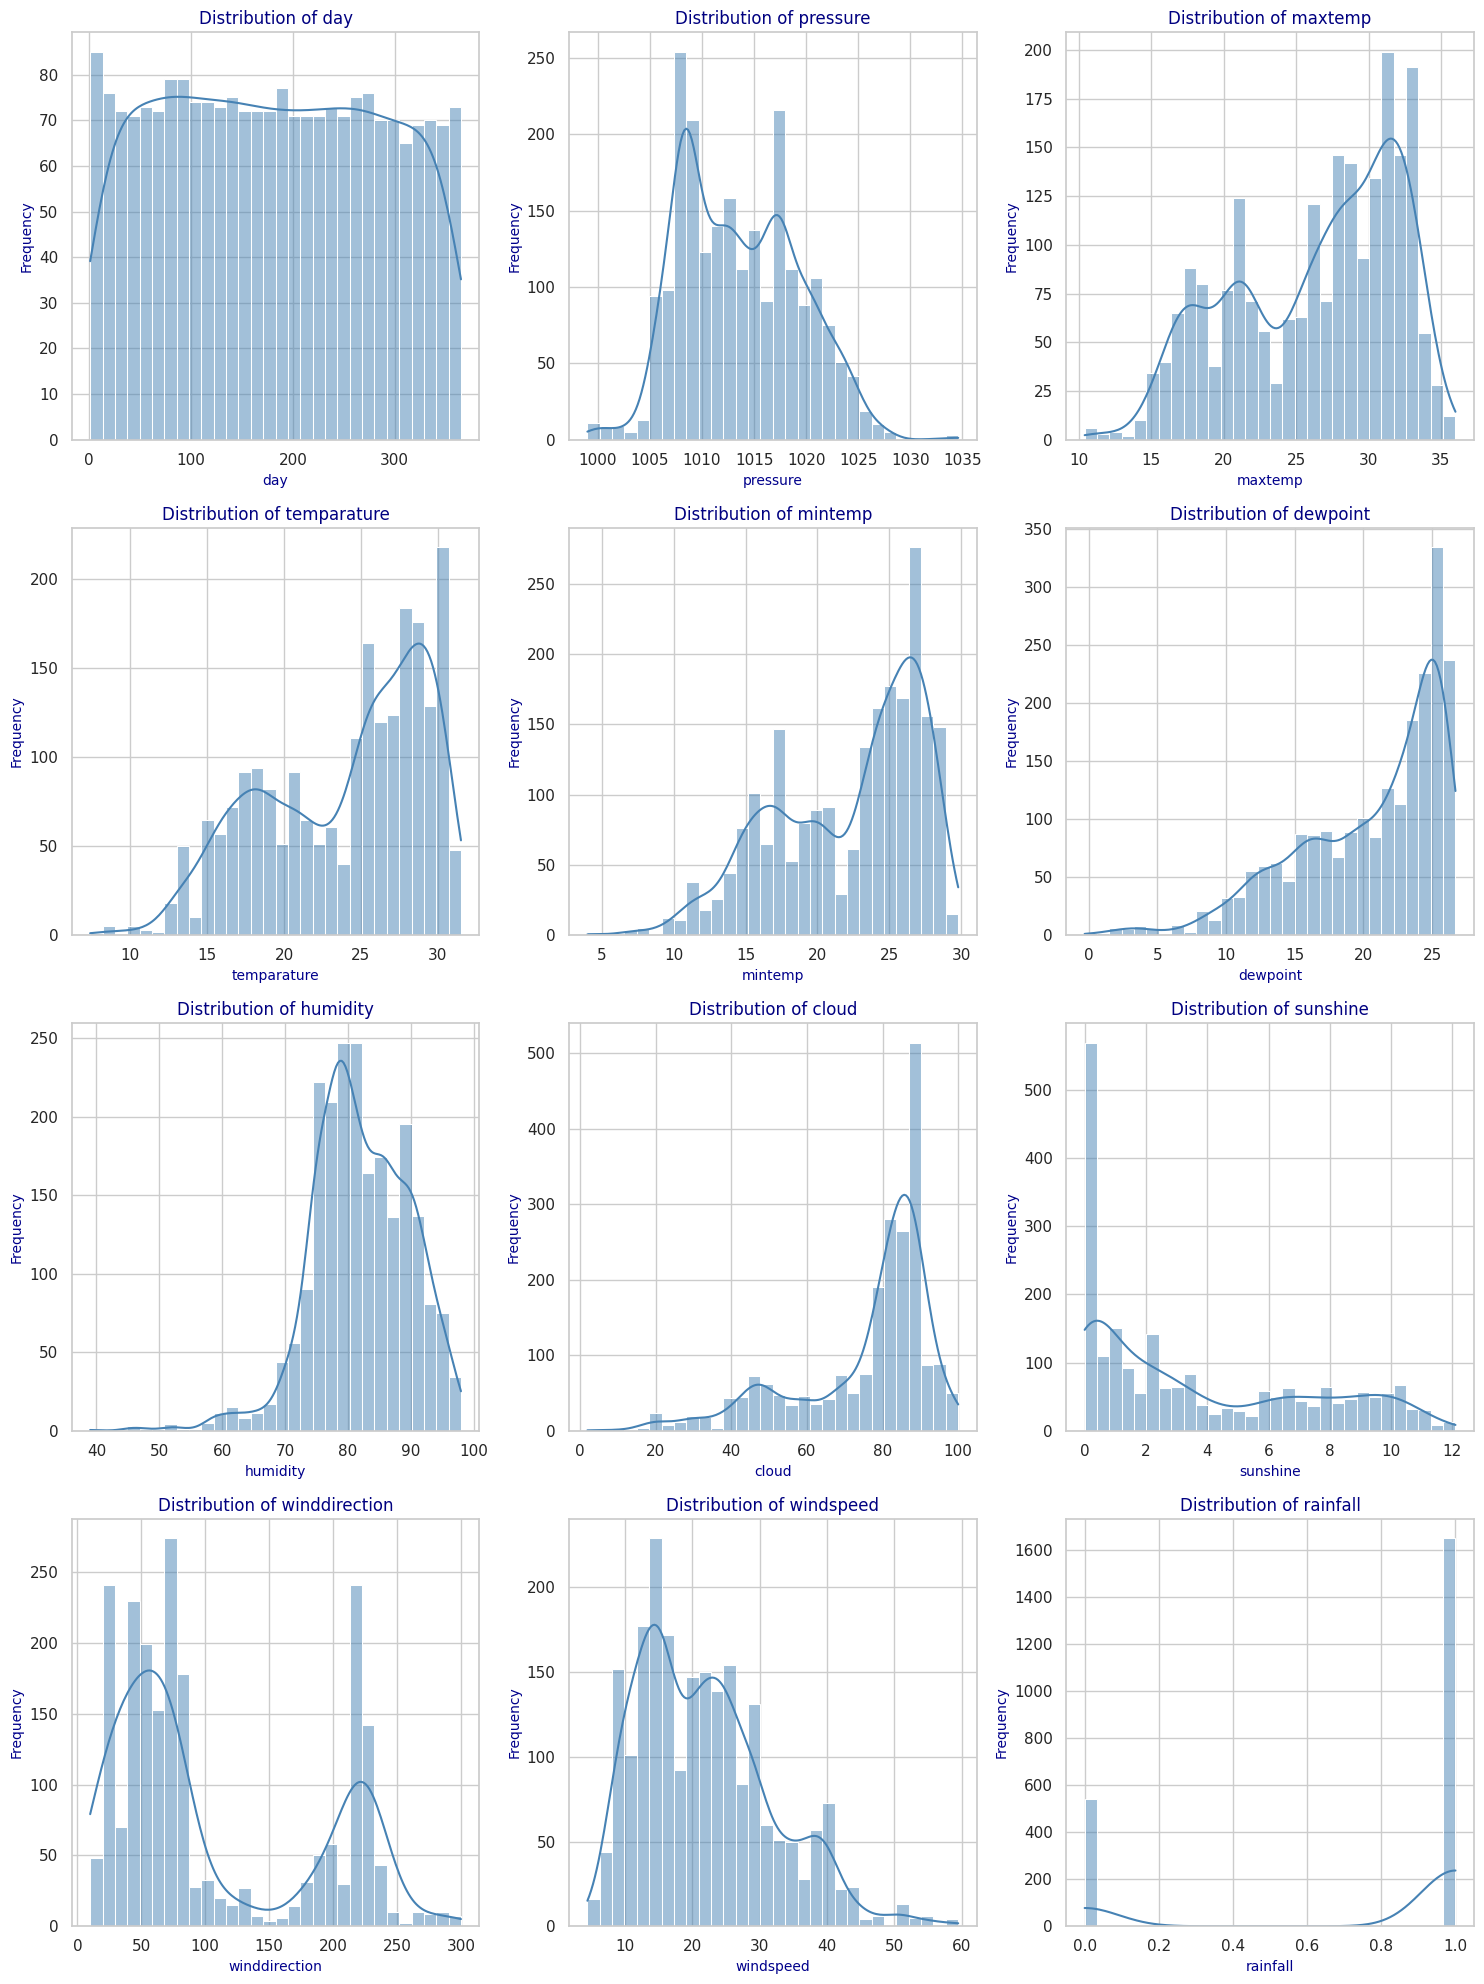

In [10]:
# Drop 'id' column it's not needed
df = train_data.drop(columns=['id'])

# List of numerical columns (ignoring 'id')
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Set a rainfall theme using Seaborn
sns.set_theme(style="whitegrid", palette="cool")  # Cool shades for a rainfall vibe

# Set up the plotting grid
plt.figure(figsize=(15, 20))  # Adjust size to fit all plots
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')  # Using steelblue for rainfall
    plt.title(f'Distribution of {col}', fontsize=12, color='navy')
    plt.xlabel(col, fontsize=10, color='darkblue')  # Axis labels with darker blue
    plt.ylabel('Frequency', fontsize=10, color='darkblue')

plt.tight_layout()
plt.show()

<div class="note">

#### Key Points Noticed

**1. Seasonality in temperature:**

The temperature, maxtemp, and mintemp distributions all look somewhat bimodal. This usually indicates a warm season (the right‐hand peak around 25–30 °C) and a cooler season (the left‐hand peak around 10–15 °C).

**2. High humidity and dewpoint:**

Humidity and dewpoint are both heavily skewed toward the higher end (70–90% humidity, dewpoint often above 20 °C), suggesting a generally warm and quite humid climate—potentially tropical or subtropical.

**3. Cloudy conditions and limited sunshine:**

Cloud coverage is skewed toward high values (70–100%), and sunshine has a big spike near zero hours. This indicates many cloudy or overcast days with only a small fraction of days that are truly clear/sunny.

**4. Wind direction is multimodal, wind speeds moderate:** 

Winddirection shows multiple peaks, implying winds come from several dominant directions during different times of year (seasonal shifts).
Windspeed is mostly moderate (around 10–20) with some higher outliers.
</div>

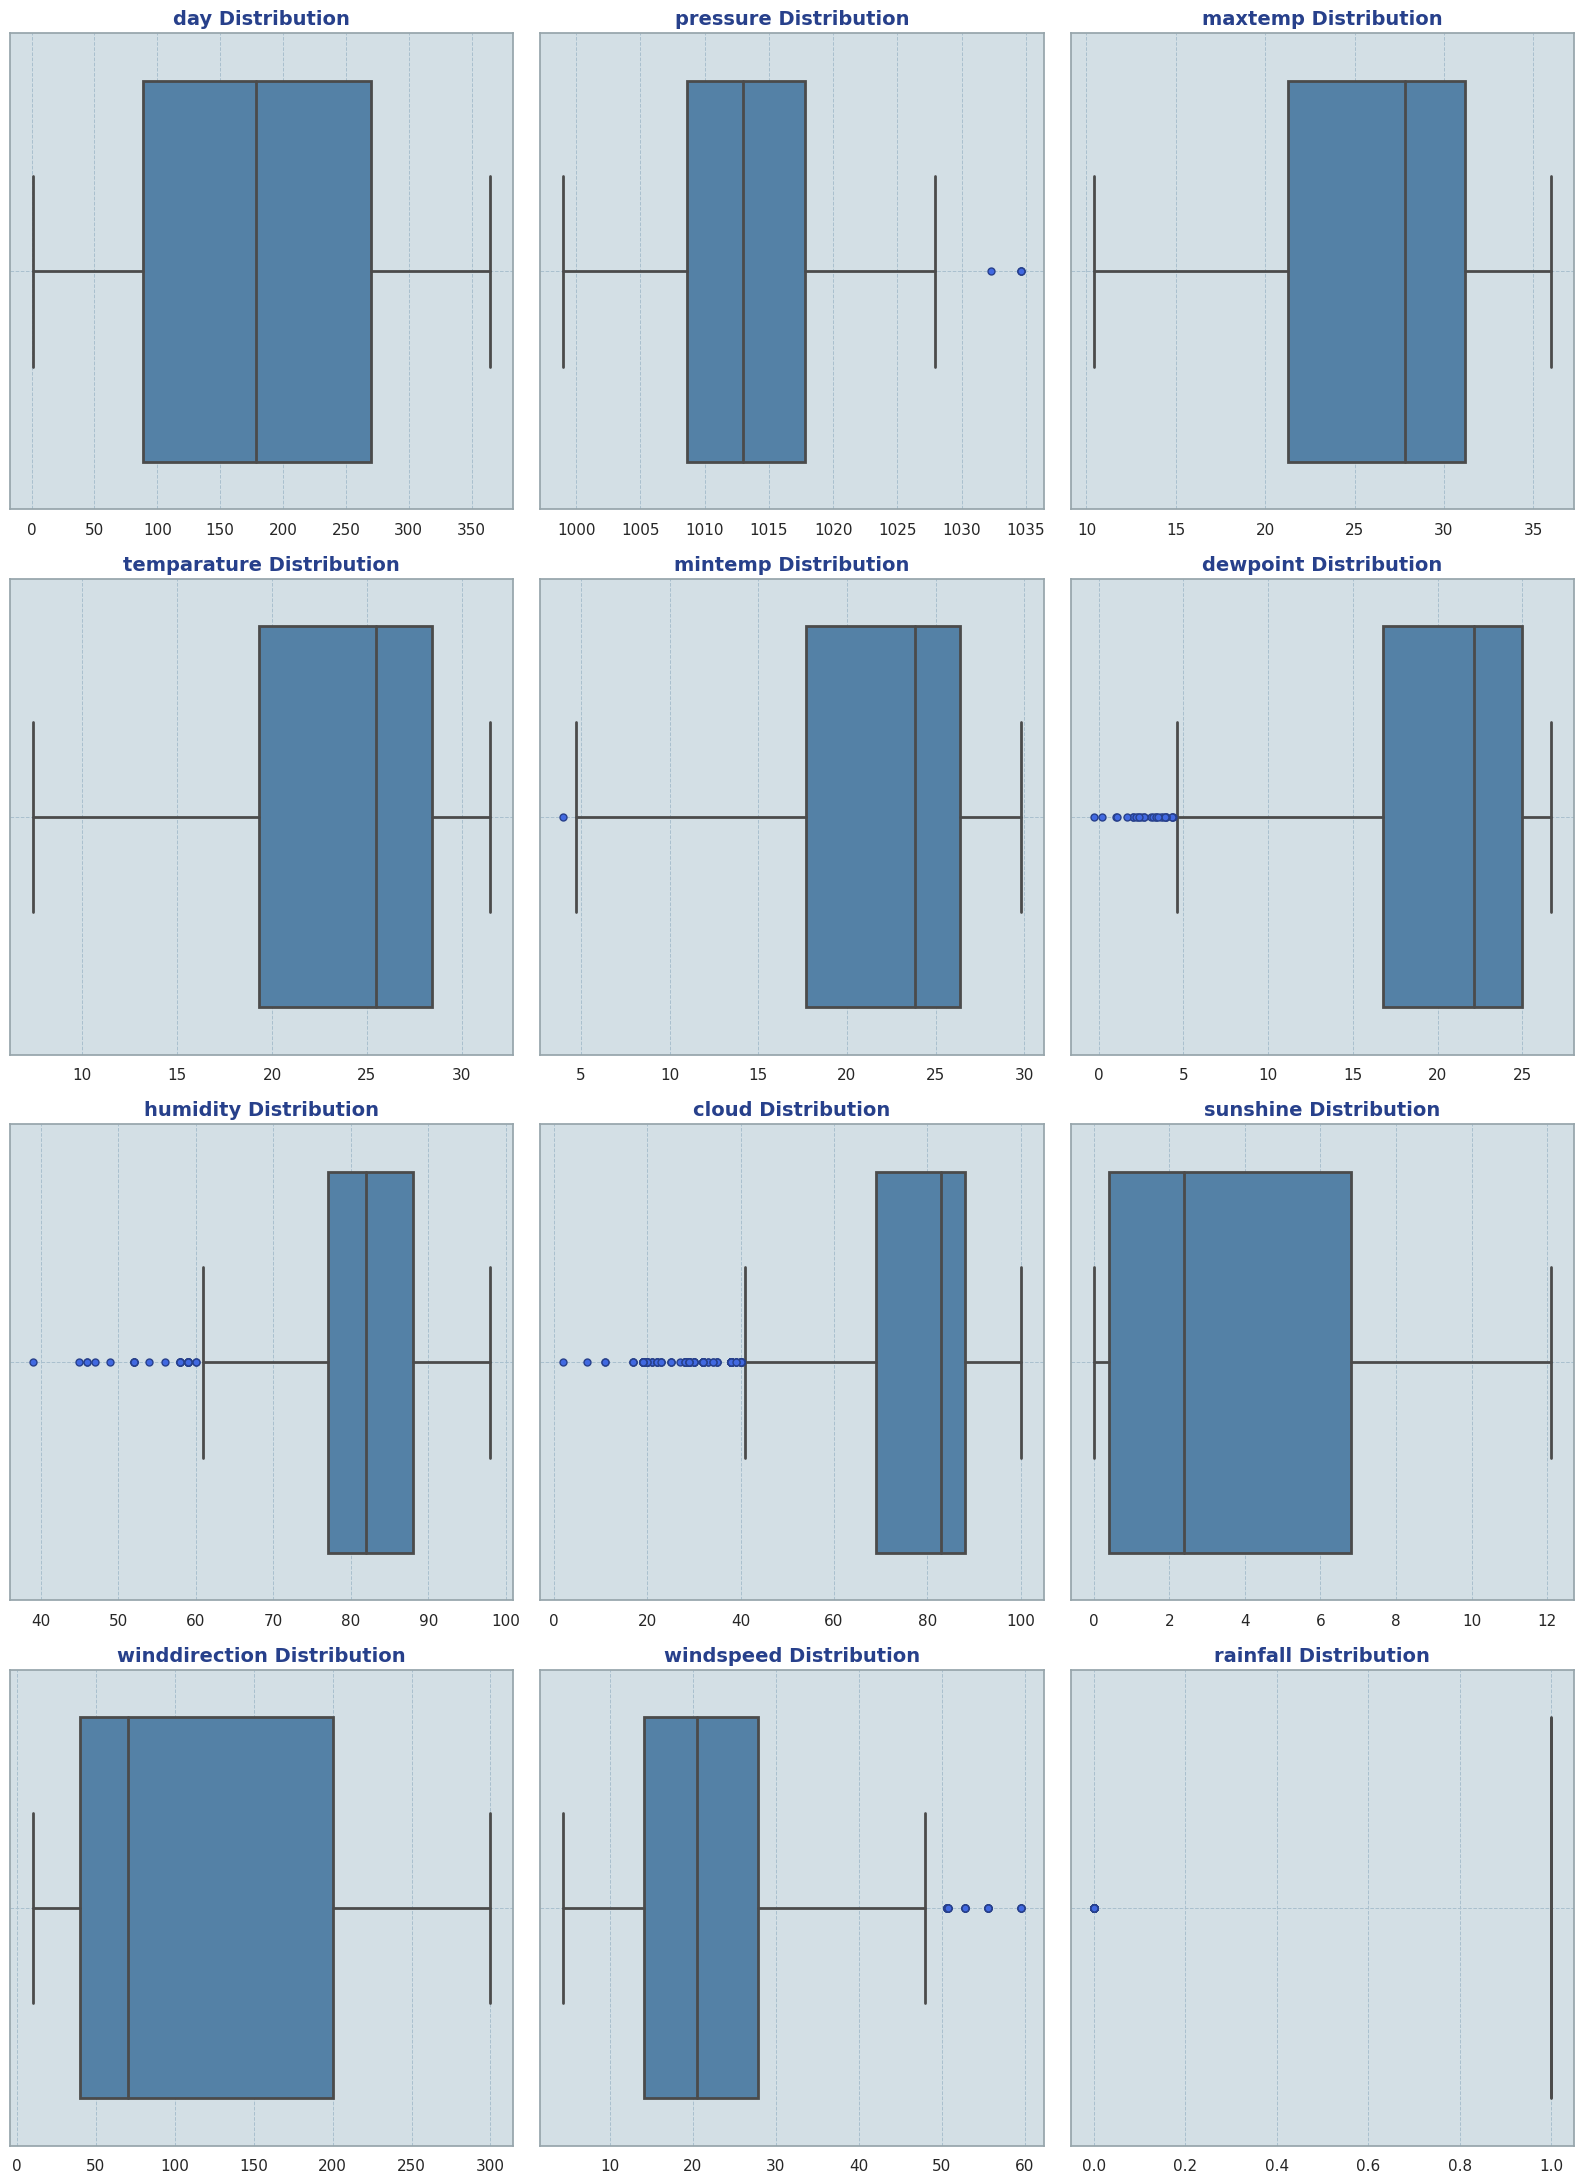

In [11]:
## For Better Outlier Detection
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#d3dfe5", "axes.edgecolor": "#96a5ab"})

plt.figure(figsize=(16, 22))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(
        data=df,
        x=col,
        color='#4682b4',
        linewidth=2,
        flierprops={'marker': 'o', 'markerfacecolor': '#4169e1', 'markeredgecolor': '#27408b', 'markersize': 5}
    )
    plt.title(f'{col} Distribution', fontsize=14, color='#27408b', weight='bold')
    plt.xlabel('', fontsize=11, color='#1c3c5a')
    plt.grid(color='#a9c0ce', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

<div class="note">

#### Key Points Noticed

**1.Rainfall is strictly 0 or 1**

Because it is binary (0 = no rain, 1 = rain), duh!

**2.High humidity and dewpoint**

The humidity box is centered around 70–90%, with a cluster of lower‐humidity days appearing as outliers (i.e., less common). Dewpoint likewise skews toward the higher end (teens to low‐20s °C), consistent with a muggy or tropical feel. -- Good Place for Vacations 🏖 

 ☺ Just a friendly reminder that while there are some outliers in the data, that's all part of the process!  ☺  -- we are not touching them

</div>

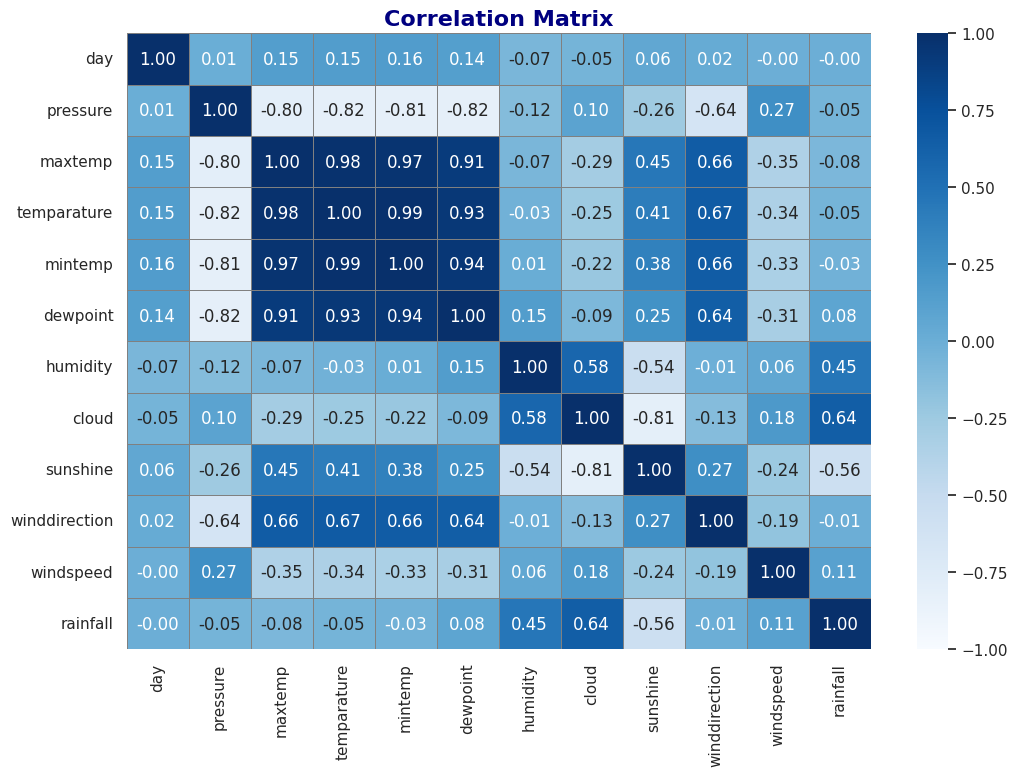

In [12]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Set up a rainfall-inspired theme
sns.set_theme(style="whitegrid", palette="cool")

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True, 
    fmt=".2f",
    cmap="Blues",
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Correlation Matrix', fontsize=16, color='navy', weight='bold')
plt.show()

<div class="note">

Overall, the matrix confirms a fairly typical meteorological story: higher temperatures pair with lower pressure, and rainy/cloudy/humid conditions oppose sunny ones. The strong cross‐correlations among temperature measures, and between cloud/humidity/rainfall, all line up with standard weather patterns.

**Moving Forward:**

Since max, min, mean temperature, and dewpoint all singing the same tune, I’d likely choose one representative temperature metric (say, mean temperature) rather than all four. Then, I'd include pressure, humidity, and cloud cover. Wind direction and wind speed round out the set, and I might keep the day variable to capture any nonlinear seasonal effects. This curated selection helps the model focus on the unique aspects of the weather without getting overwhelmed by overlapping information. 
                                    
                                     -- But lets analyze more and Time Series Next ⌚ 🤜 
</div>

In [13]:
# Group data by Rainfall (0 or 1)
grouped_data = df.groupby('rainfall').mean()

# Display summary statistics
print("Mean Values for Each Group:")
grouped_data

Mean Values for Each Group:


,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
rainfall,,,,,,,,,,,
0,180.033333,1014.095185,27.149444,24.406296,22.407407,19.697037,75.844444,55.522222,7.263519,105.833333,19.873704
1,179.920606,1013.440788,26.109333,23.804727,22.092424,20.702485,84.063030,82.332727,2.592727,104.545636,22.436667


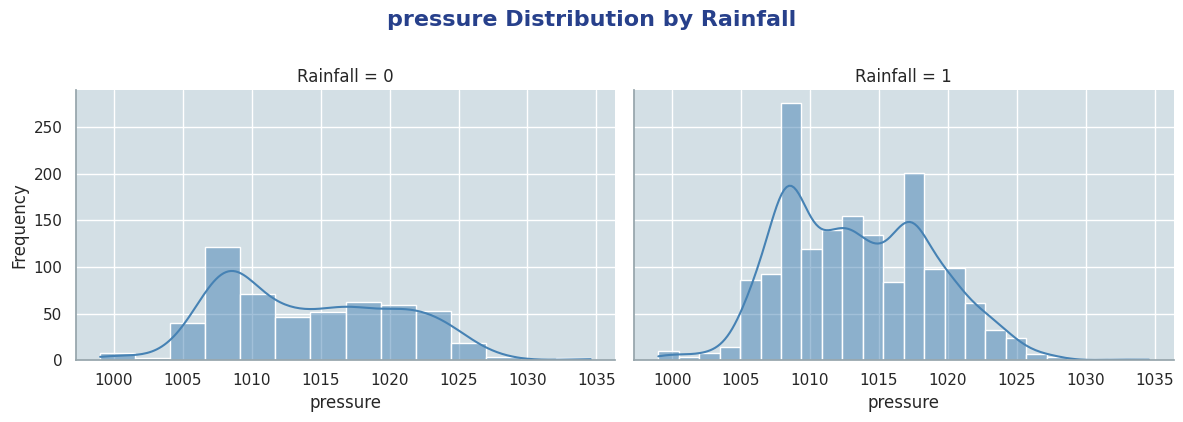

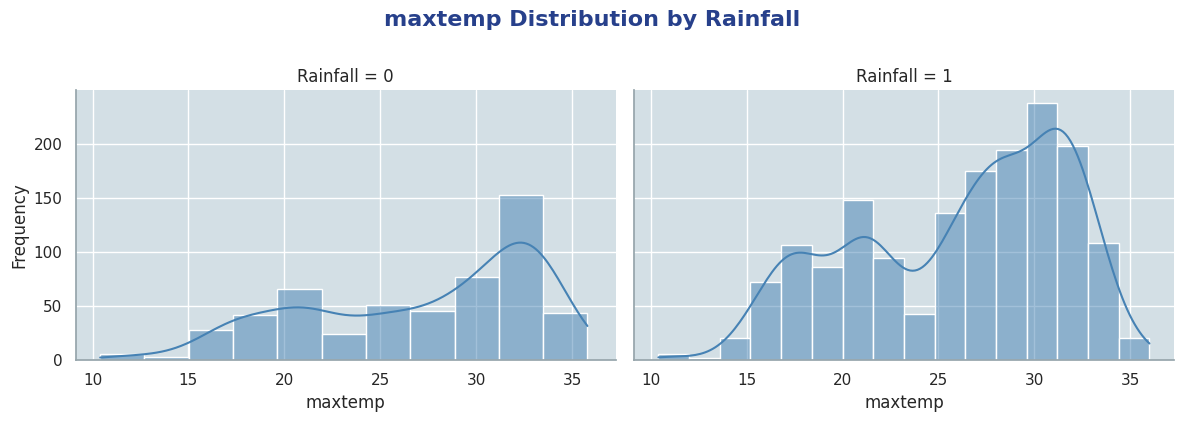

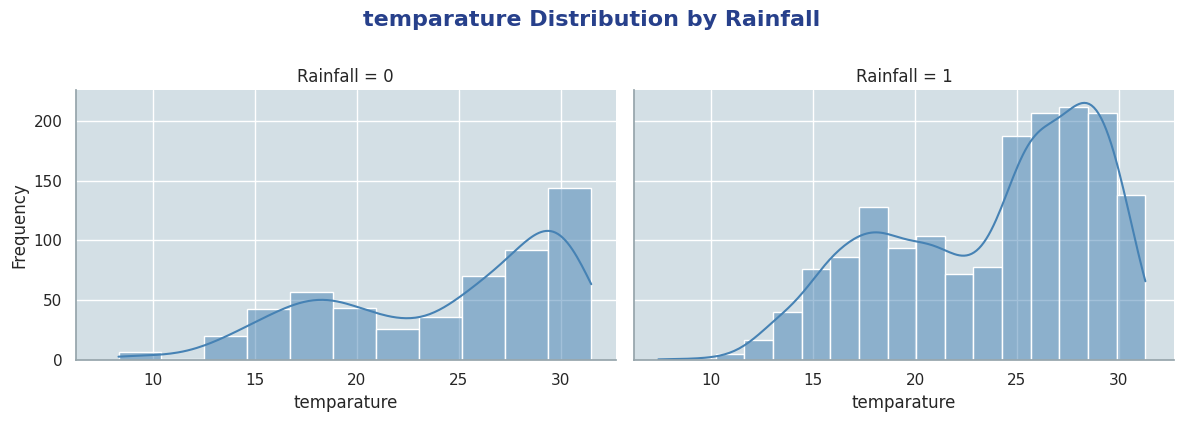

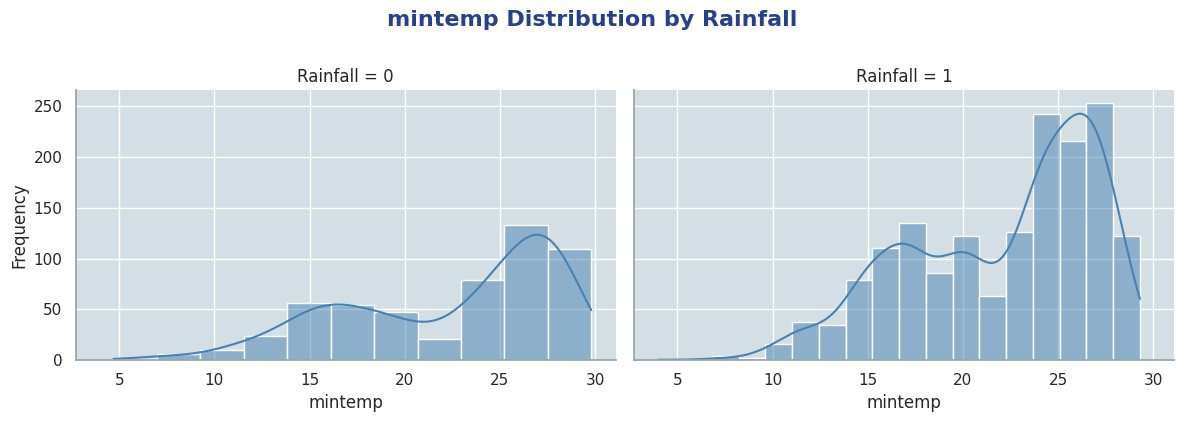

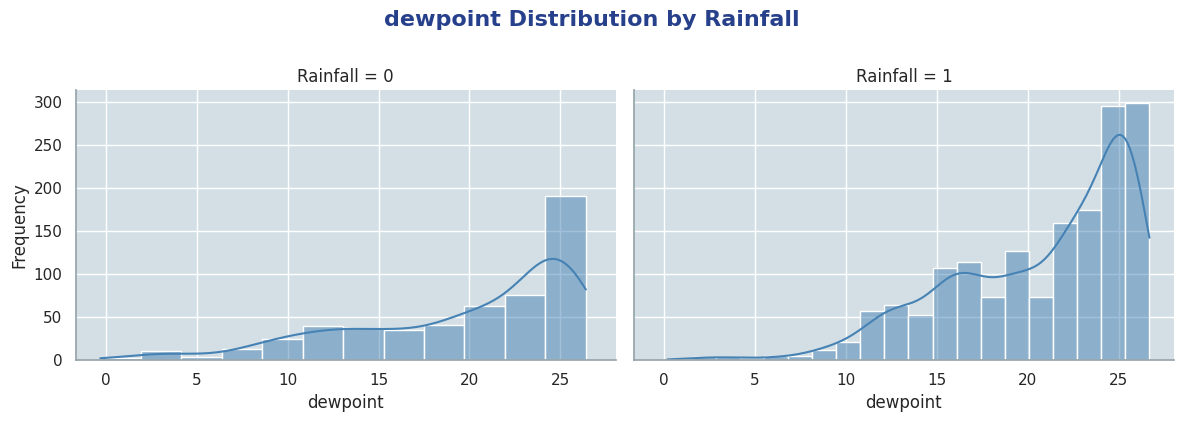

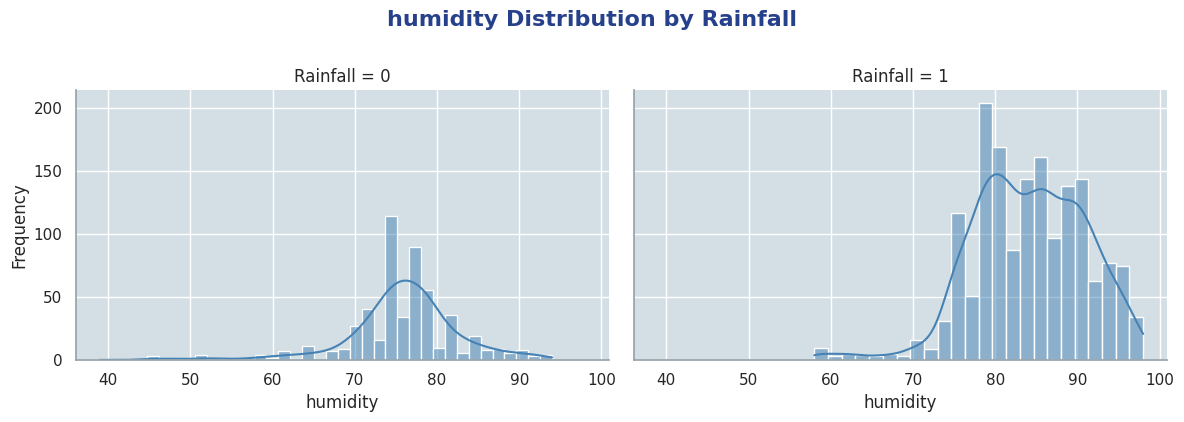

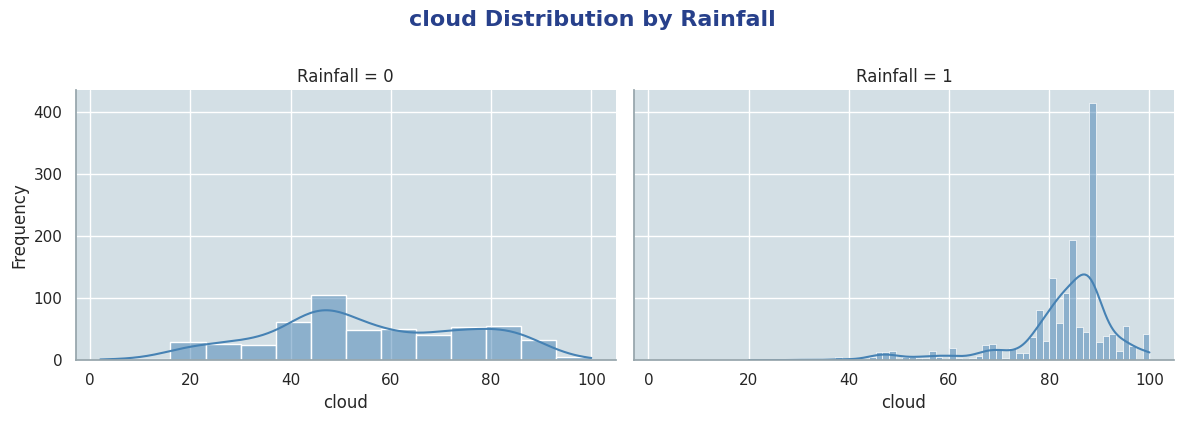

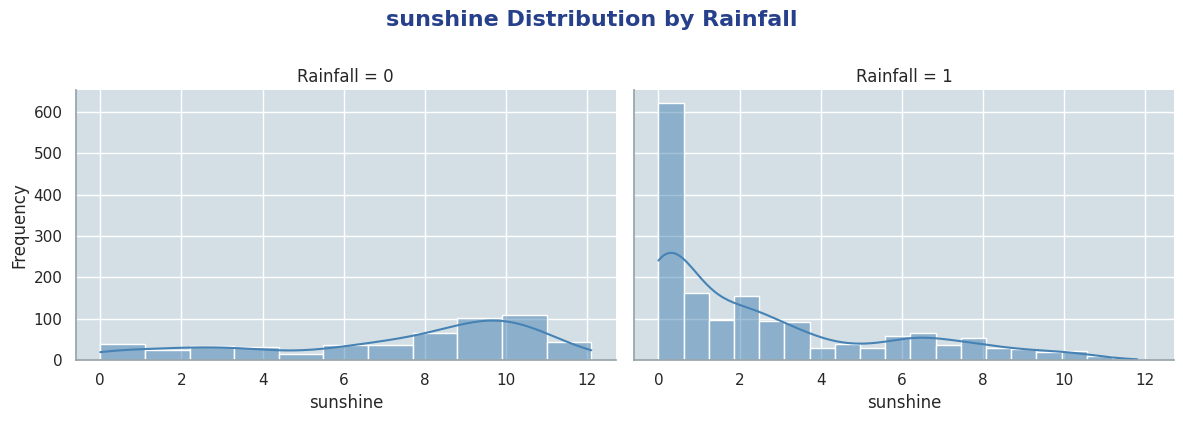

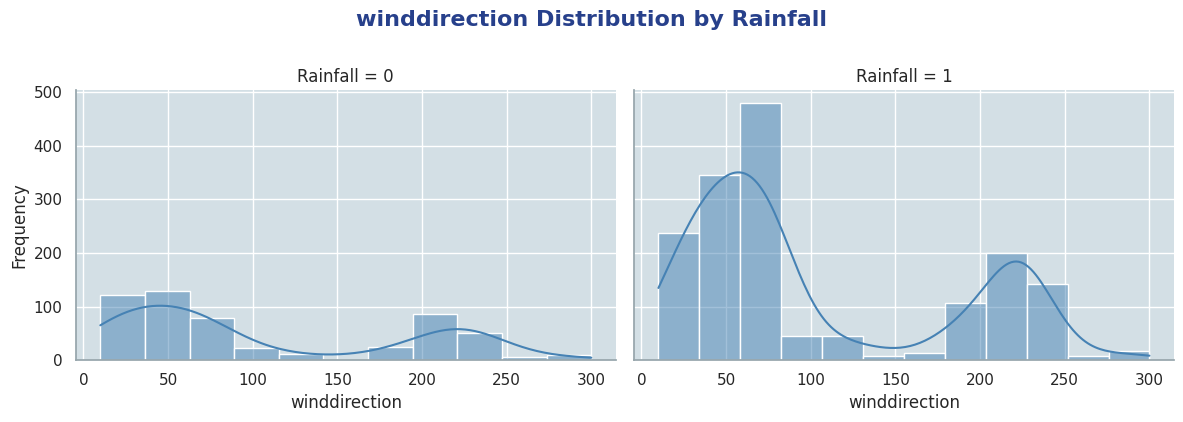

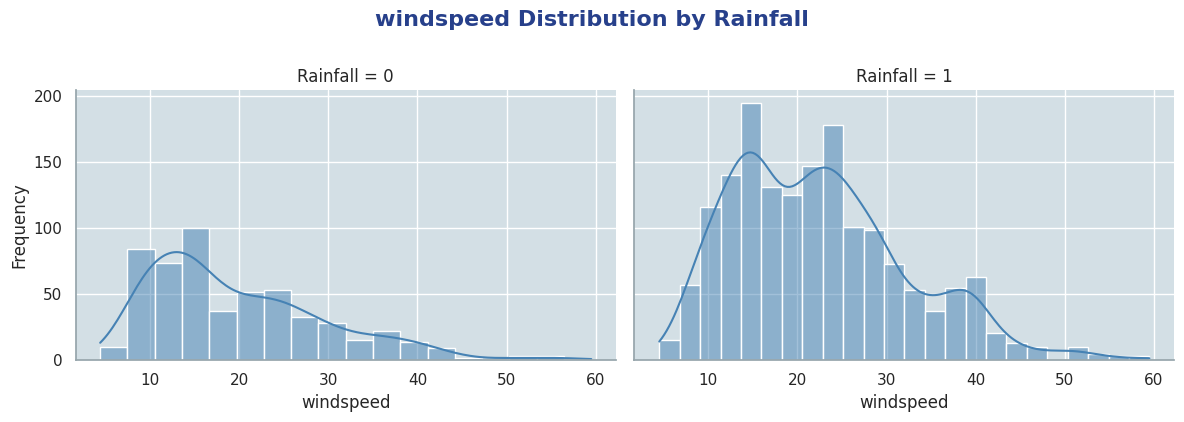

In [14]:
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#d3dfe5", "axes.edgecolor": "#96a5ab"})

variables_to_plot = df.columns.drop(['rainfall', 'day'])

for col in variables_to_plot:
    g = sns.FacetGrid(df, col="rainfall", height=4, aspect=1.5, palette="Blues")
    g.map(sns.histplot, col, kde=True, color='#4682b4')
    g.set_titles("Rainfall = {col_name}")
    g.fig.suptitle(f"{col} Distribution by Rainfall", fontsize=16, color='#27408b', weight='bold', y=1.05)
    g.set_axis_labels(x_var=col, y_var='Frequency')
    g.fig.subplots_adjust(top=0.85)
    plt.show()

<div class="note">

A quick review on a few strong clues about when it rains versus when it doesn’t:

**Pressure:** On rainy days, the distribution leans toward lower pressure (centered around ~1010 hPa), whereas on dry days it’s shifted higher. That’s the classic storm‐system signal—low pressure often brings precipitation.

**Temperatures (max/mean/min):** Rainy days still get warm (peaking around the mid‐20s to low 30s °C), but overall max temps tend to be a bit lower on rainy days than on clear days.

**Dewpoint & Humidity:** Both are noticeably higher when it rains—no surprise there, as more moisture in the air typically leads to precipitation.

**Cloud Cover & Sunshine:** Rainy days are dominated by heavy cloud cover (70–100%) and minimal sunshine (often near 0 hours). Dry days have a broader range of cloud cover, and more sunshine on average.

**Wind Direction & Speed:** Certain wind directions appear more common on rainy days (possibly bringing in moist air), and wind speeds can be a bit higher too—though there’s some overlap between rainy and non‐rainy distributions.

All in all, these charts confirm the classic pattern: lower pressure, higher moisture, and heavier cloud cover go hand in hand with rainfall, while clear, sunny skies accompany higher pressure and lower humidity.
</div>

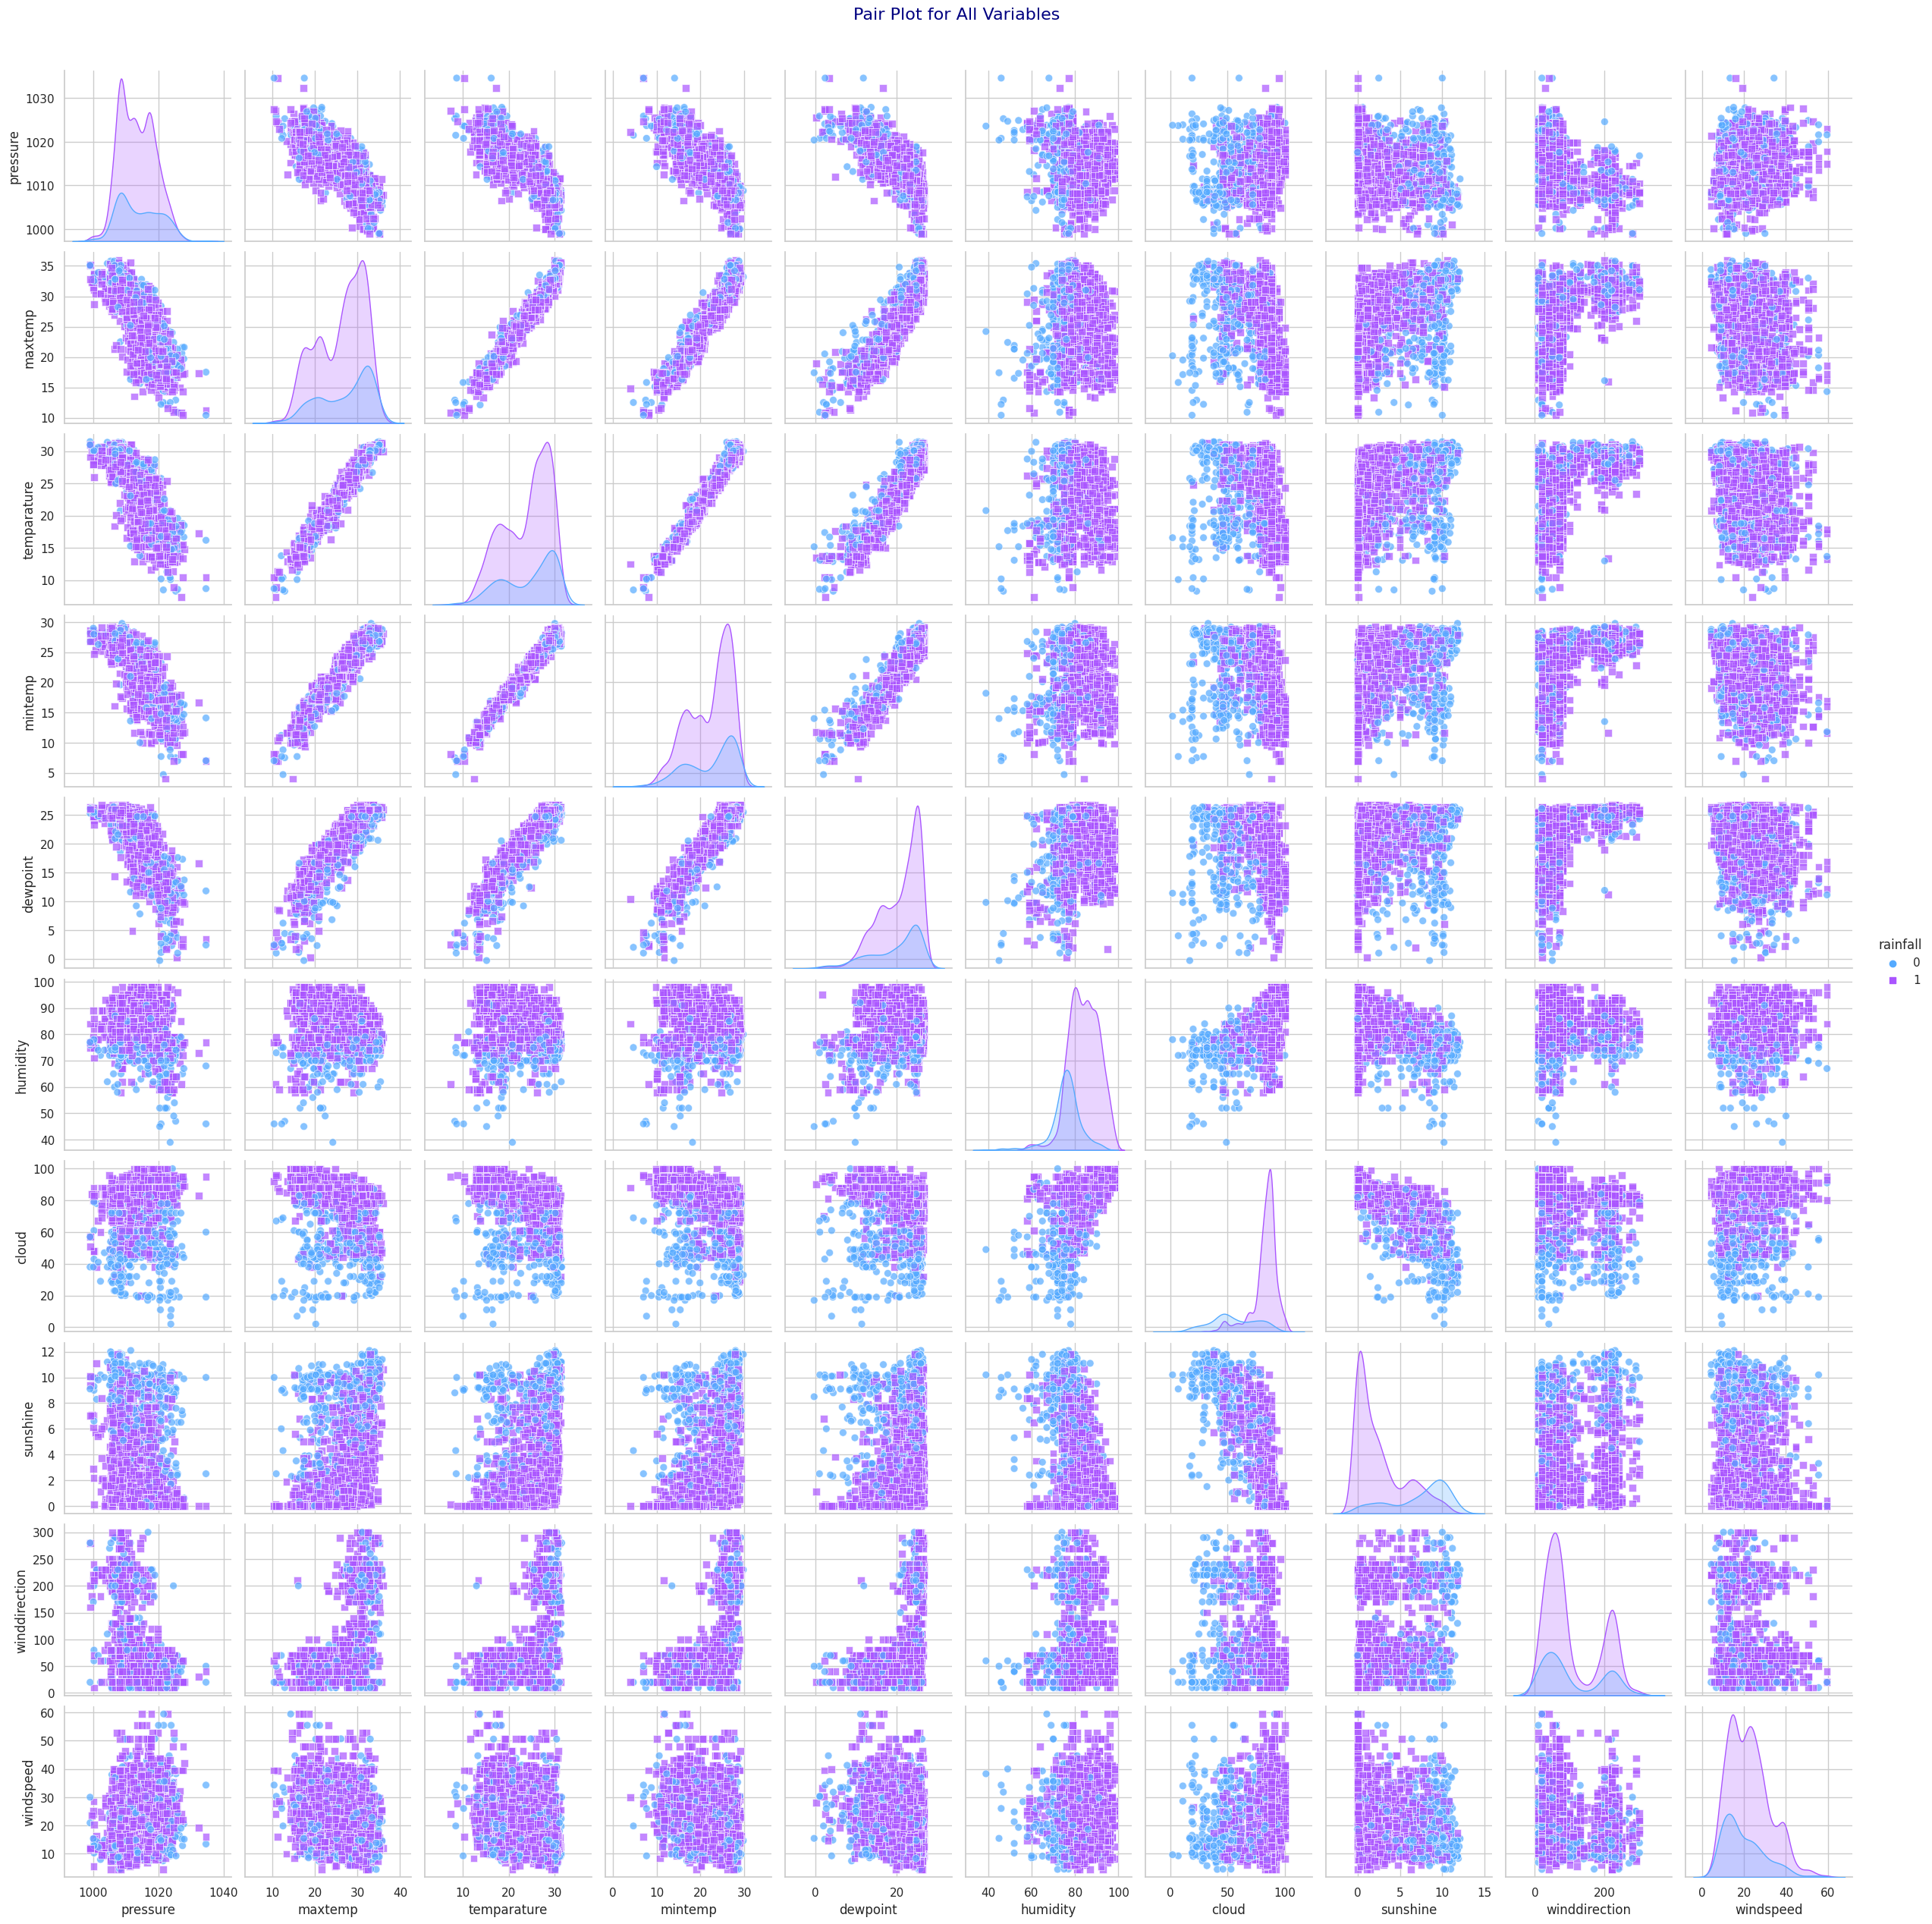

In [15]:
# Dropping 'id' and 'day'
numerical_columns = train_data.select_dtypes(include=['float64', 'int64']).columns.drop(['id','day'])

# Creating a pair plot
sns.set_theme(style="whitegrid")
pair_plot = sns.pairplot(
    df[numerical_columns],
    hue="rainfall",  # Color by rainfall (0 = No rain, 1 = Rain)
    palette="cool",  # Rain-themed palette
    diag_kind="kde",  # Kernel Density Estimate on the diagonal
    markers=["o", "s"],  # Different markers for groups
    plot_kws={"alpha": 0.7, "s": 50}  # Transparency and marker size
)

pair_plot.fig.suptitle("Pair Plot for All Variables", y=1.02, fontsize=16, color="navy")
plt.show()

<div class="note">
From these pair plots, you can spot several telling “weather signatures” just by eyeing where the rainy (purple squares) versus dry (blue circles) points cluster:

**Pressure & Temperature:** Rainy points tend to clump around lower pressure values, while dry days lean higher. Meanwhile, all temperature variables (max, mean, min) track closely together—no shock given their strong correlations.

**Humidity & Dewpoint:** Rainy days usually show up in the high‐humidity/high‐dewpoint corner, which fits the classic pattern that more moisture in the air raises the odds of rainfall.

**Cloud & Sunshine:** The scatter plots reveal a pretty direct trade‐off: rainy days are clustered where cloud coverage is higher and sunshine is lower. Clear days occupy the opposite corner.

**Wind:** Certain wind directions and speeds line up more with rain than others, though there’s still overlap. Stronger or differently directed winds may bring in moist air.
Redundant Variables

*The diagonal plots and strong linear relationships (like among max temp, mean temp, and min temp) hint that some variables might be redundant for modeling.* 

Overall, the pair plot underscores the usual suspects for predicting rainfall—pressure, humidity, dewpoint, and cloud cover—while also confirming that temperature measures march in lockstep, so we probably don’t need to keep all of them in a predictive model.

<div class="note">
Based on all these plots and correlations, a concise set of features would typically include:

- Pressure (strong signal for rain vs. no rain)
- A single Temperature measure (e.g., mean or max, since all are highly correlated)
- Humidity (closely tied to moisture in the air)
- Cloud cover (heavily linked to rainfall events)
- Sunshine (helps capture the inverse relationship with cloudiness/rain)
- Wind speed and direction (certain wind patterns bring moist or dry air)
- (Optionally) Day or a transformed day‐of‐year feature to capture seasonal trends if they exist
 
Dewpoint could be substituted for (or used alongside) humidity, but typically one moisture variable is enough to avoid redundant information.
</div>

<h2 class="subtitle">Time Series Analysis ⌚ ☀ ☔ ❄ </h2>

In [16]:
df['date'] = pd.to_datetime('2021-01-01') + pd.to_timedelta(df['day'] - 1, unit='D')
## We were provided 365 days so - i believe it is from same year

In [17]:
# Select only numeric columns (excluding 'id')
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# If you don't want to include 'day' in the aggregation, remove it:
numeric_cols = [col for col in numeric_cols if col not in ['day']]

# Now, group by date and take the mean of numeric columns
daily_avg = df.groupby('date')[numeric_cols].mean().reset_index()

daily_avg.head()

,date,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,2021-01-01,1016.583333,18.533333,17.333333,16.333333,16.366667,91.166667,93.833333,0.216667,45.000000,29.833333,1.000000
1,2021-01-02,1016.516667,19.550000,18.066667,16.700000,15.783333,91.666667,94.500000,0.100000,51.666667,30.416667,1.000000
2,2021-01-03,1016.257143,20.342857,17.971429,17.057143,13.342857,81.000000,79.857143,2.985714,62.857143,39.857143,0.857143
3,2021-01-04,1017.957143,19.985714,18.285714,16.642857,15.600000,82.571429,79.000000,1.842857,61.428571,40.457143,0.714286
4,2021-01-05,1021.628571,17.200000,15.342857,13.728571,9.657143,70.285714,73.571429,2.714286,65.714286,28.714286,0.714286


In [18]:
plot_vars = ['pressure', 'maxtemp', 'temparature', 'mintemp', 
             'dewpoint', 'humidity', 'cloud', 'sunshine', 
             'winddirection', 'windspeed']

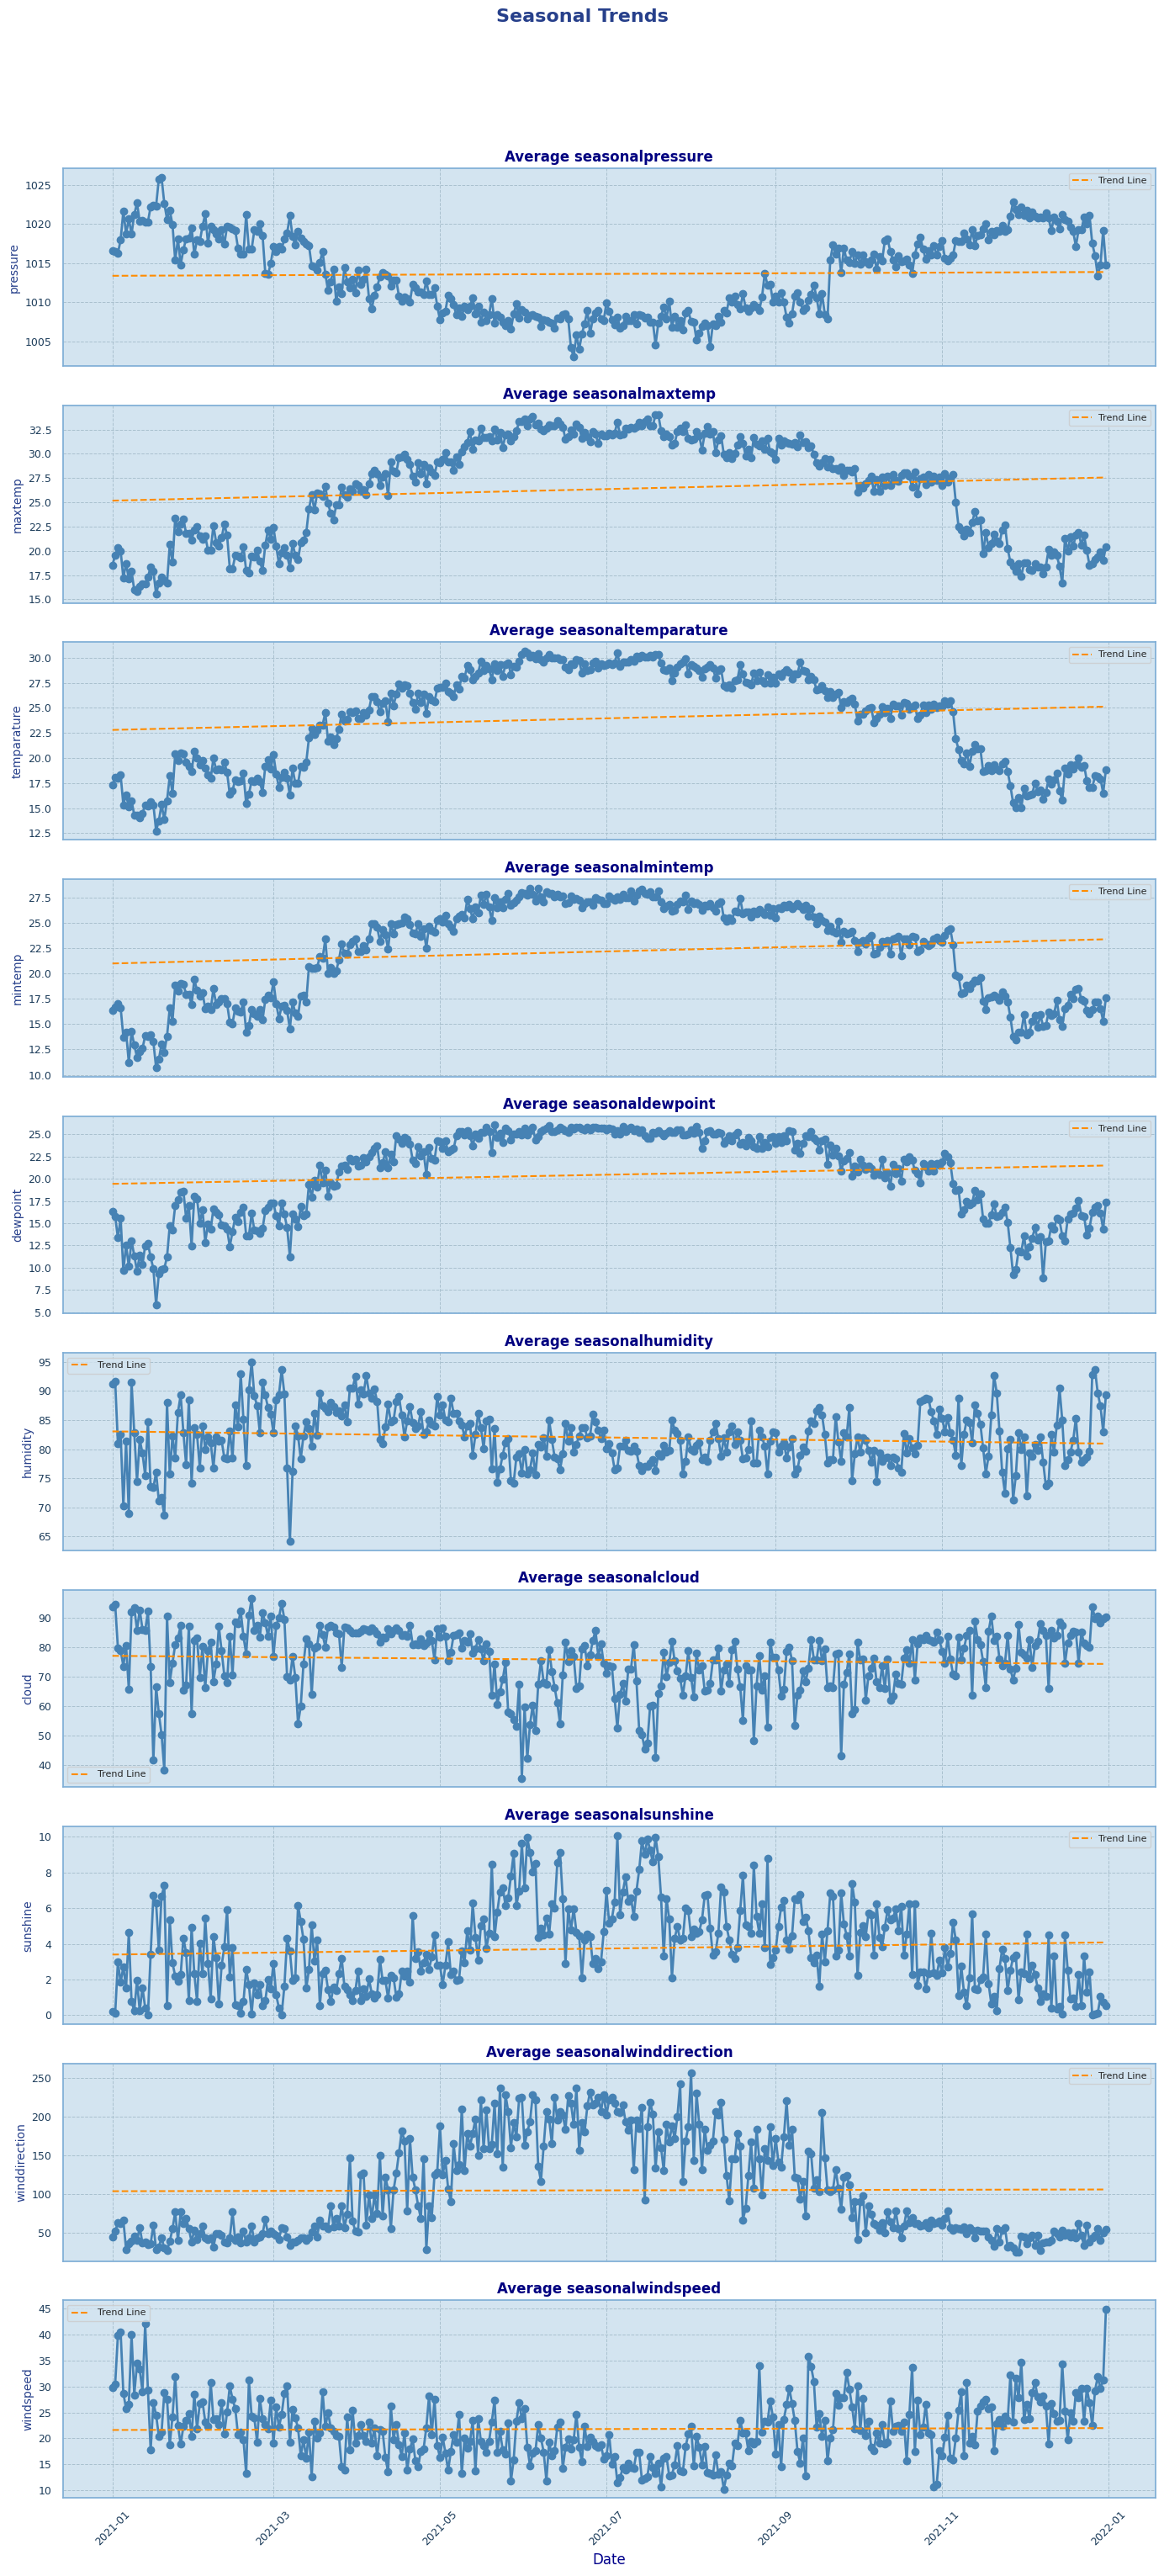

In [19]:
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#d3e4f0", "axes.edgecolor": "#7eaed6"})

fig, axes = plt.subplots(nrows=len(plot_vars), ncols=1, figsize=(14, 3 * len(plot_vars)), sharex=True)

for ax, var in zip(axes, plot_vars):
    # Plot the data points
    ax.plot(daily_avg['date'], daily_avg[var], marker='o', linestyle='-', color='steelblue', linewidth=2, markersize=6)

    # Add a trend line by calculating the line of best fit
    x = np.arange(len(daily_avg['date']))
    y = daily_avg[var]
    z = np.polyfit(x, y, 1)  # Linear fit (degree 1)
    trend = np.poly1d(z)

    # Plot the trend line
    ax.plot(daily_avg['date'], trend(x), color='darkorange', linestyle='--', linewidth=1.5, label='Trend Line')

    ax.set_title(f"Average seasonal{var}", fontsize=12, color='navy', weight='bold')
    ax.set_ylabel(var, fontsize=10, color='#27408b')
    ax.grid(color='#a9c0ce', linestyle='--', linewidth=0.7)
    ax.tick_params(axis='x', rotation=45, labelsize=9, colors='#1c3c5a')
    ax.tick_params(axis='y', labelsize=9, colors='#1c3c5a')
    ax.legend(fontsize=8)  # Add legend for the trend line

plt.xlabel("Date", fontsize=12, color='darkblue')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Seasonal Trends", y=1.02, fontsize=16, color='#27408b', weight='bold')
plt.show()

<div class="note">
1. Pressure is high in the cooler months, dips in the middle of the year, and then climbs again, following a seasonal swing.

2. Temperatures (max, mean, min) all ramp up into summer and then decline toward winter, showing a strong annual cycle.

3. Dewpoint and Humidity follow a similar seasonal wave, peaking when it’s warm and moisture is high.

4. Cloud cover and Sunshine clearly move in opposite directions (cloudier conditions correspond to lower sunshine).

5. Wind direction shifts dramatically, suggesting that certain times of year bring wind from distinctly different headings.

6. Wind speed trends downward through the year but also shows peaks that might coincide with storms or fronts.

In [20]:
train_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


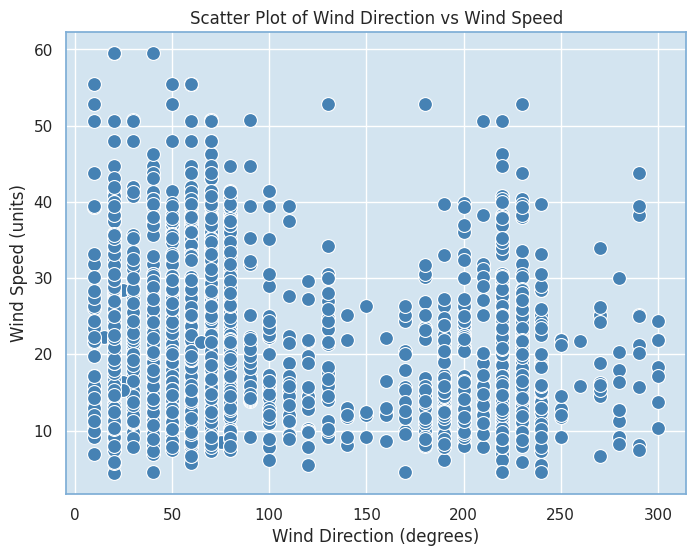

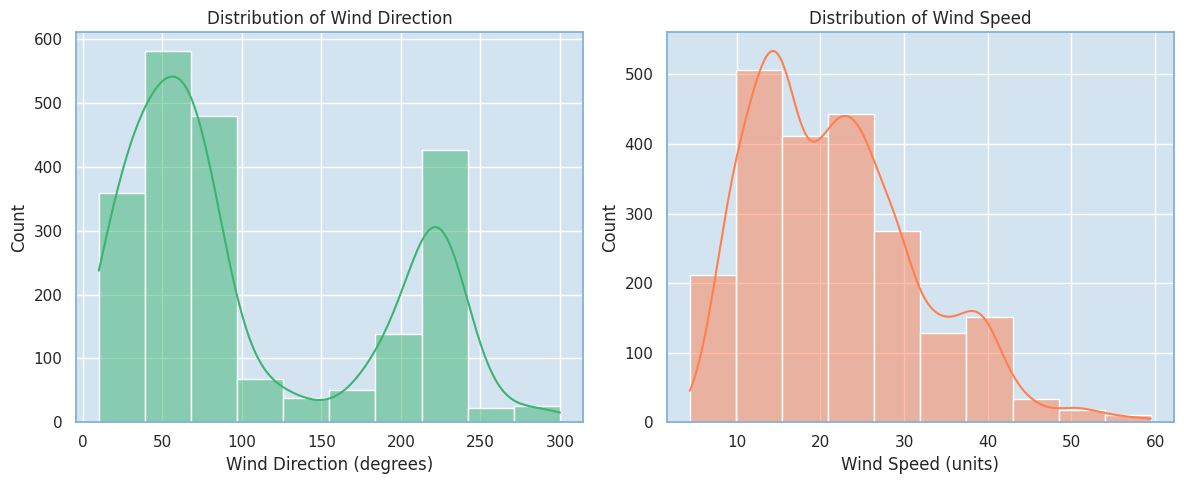

In [21]:
# Scatter plot: Wind Direction vs Wind Speed
plt.figure(figsize=(8, 6))
sns.scatterplot(x='winddirection', y='windspeed', data=train_data, s=100, color='steelblue')
plt.xlabel("Wind Direction (degrees)")
plt.ylabel("Wind Speed (units)")
plt.title("Scatter Plot of Wind Direction vs Wind Speed")
plt.grid(True)
plt.show()

# Distribution plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_data['winddirection'], bins=10, kde=True, color='mediumseagreen')
plt.xlabel("Wind Direction (degrees)")
plt.title("Distribution of Wind Direction")

plt.subplot(1, 2, 2)
sns.histplot(train_data['windspeed'], bins=10, kde=True, color='coral')
plt.xlabel("Wind Speed (units)")
plt.title("Distribution of Wind Speed")

plt.tight_layout()
plt.show()

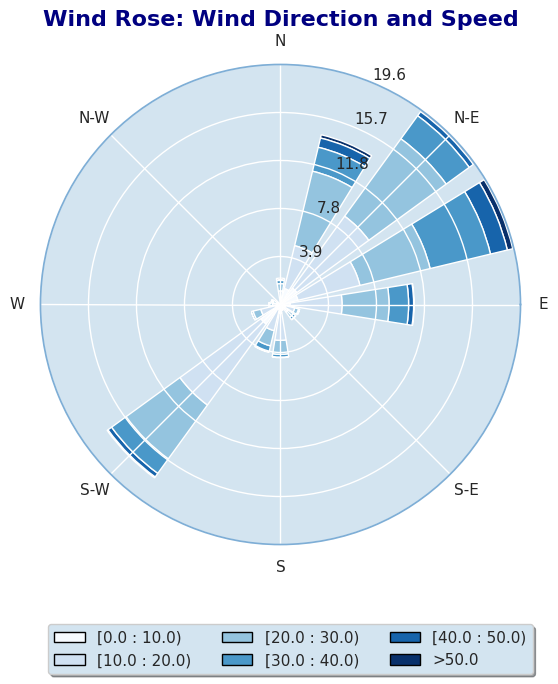

In [22]:
fig = plt.figure(figsize=(8, 6))
ax = WindroseAxes.from_ax(fig=fig)
ax.patch.set_facecolor("#d3e4f0")  # Light blue background for a rainfall theme

# Plot the wind rose with a blue colormap and defined bins
ax.bar(df['winddirection'], df['windspeed'], normed=True, opening=0.8,
       edgecolor='white', bins=[0, 10, 20, 30, 40, 50], cmap=plt.cm.Blues)

# Set the title with styling
ax.set_title("Wind Rose: Wind Direction and Speed", color='navy', fontsize=16, weight='bold')

# Create the legend with a light background and navy text
legend = ax.legend(title="Wind Speed (units)", fontsize=10, title_fontsize=12,
                   facecolor="#f0f8ff", edgecolor='navy')
plt.setp(legend.get_texts(), color='navy')  # Ensure legend text is visible

# Reposition the legend outside the plot area to avoid overlap
ax.legend(loc='upper left', bbox_to_anchor=(0.0, -0.15), ncol=3, frameon=True, fancybox=True, shadow=True)

plt.show()

<div class="note">the wind rose reveals that winds blow most often from the NE at moderate to high speeds, with secondary contributions from other directions at generally lower speeds.

<h2 class="subtitle"> Feature Engineering and Model Training🥅 👌 </h2>

In [23]:
#Cyclical Encoding for “day”

# For the train data
train_data['sin_day'] = np.sin(2 * np.pi * train_data['day'] / 365)
train_data['cos_day'] = np.cos(2 * np.pi * train_data['day'] / 365)

# For the test data
test_data['sin_day'] = np.sin(2 * np.pi * test_data['day'] / 365)
test_data['cos_day'] = np.cos(2 * np.pi * test_data['day'] / 365)

In [24]:
features = [
    'pressure', 'temparature', 'dewpoint', 'humidity',
    'cloud', 'windspeed', 'winddirection', 'sin_day', 'cos_day'
]

In [25]:
X = train_data[features]
y = train_data['rainfall']

In [26]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

# Define a dictionary of models to test
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# TimeSeriesSplit cross-validation
tscv = TimeSeriesSplit(n_splits=5)
fold = 1

# Loop through each split and each model
for train_index, val_index in tscv.split(X):
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    print(f"Fold {fold} Results:")
    for name, model in models.items():
        model.fit(X_train_cv, y_train_cv)
        y_val_pred = model.predict(X_val_cv)
        print(f"{name} Classification Report:")
        print(classification_report(y_val_cv, y_val_pred))
    fold += 1

Fold 1 Results:
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.71        90
           1       0.90      0.93      0.91       275

    accuracy                           0.87       365
   macro avg       0.83      0.80      0.81       365
weighted avg       0.86      0.87      0.87       365

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        90
           1       0.88      0.92      0.90       275

    accuracy                           0.84       365
   macro avg       0.79      0.76      0.77       365
weighted avg       0.83      0.84      0.84       365

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.64      0.67        90
           1       0.89      0.91      0.90       275

    accuracy                           0.84

These fold-by-fold reports show consistent performance across time splits. Overall, you’re achieving around 84–87% accuracy with a weighted F1-score in the mid-80s. Here’s what we can take from it:

**Consistency:** 
- The model performs similarly across all five folds. This consistency suggests that your model generalizes reasonably well over time.

**Class Imbalance:** 
- Class 1 (rainfall) has higher precision, recall, and F1 scores compared to class 0. This might indicate some class imbalance or that the features are more predictive for rainfall than for no rainfall. It may be worth investigating the distribution of classes in your data.

**Room for Improvement:** 
- The performance is good, but there’s potential for improvement. You might:

**Tune Hyperparameters:** 
- Experiment with different numbers of trees, max depth, or other parameters in your Random Forest (or try different models).

**Feature Engineering:** 
- Consider adding more weather-related features (e.g., rolling averages, lag features) or refining the cyclical encoding of the day.

**Balance the Data:** 
- If class imbalance is significant, consider techniques like class weighting, oversampling the minority class, or using different evaluation metrics that better reflect your business objective. -- This might provide a better Performing model but it is not recommended, Rainfall is seasonal and Time Dependent balancing data will hamper this basic understanding.

Overall, these metrics are promising and give you confidence in the model’s ability to predict rainfall in a time-aware setting, though further tuning and feature refinement could boost performance even more.

In [27]:
from sklearn.impute import SimpleImputer
X_test = test_data[features]

# Handle missing values by filling them with median (recommended for RF)
imputer = SimpleImputer(strategy="median")
X_test = pd.DataFrame(imputer.fit_transform(X_test), columns=features)

# Check feature order consistency
X_test = X_test[model.feature_names_in_] 

In [28]:
# Make predictions
rainfall_probs = model.predict_proba(X_test)[:, 1]  # Get probability of rain

In [29]:
# Prepare submission file
submission = pd.DataFrame({
    'id': test_data['id'],
    'rainfall': rainfall_probs
})

# Save as CSV
submission.to_csv("submission.csv", index=False)

print("✅ Submission file saved successfully!")

✅ Submission file saved successfully!


In [30]:
submission = pd.read_csv('submission.csv')
submission.head(10)

,id,rainfall
0,2190,0.987912
1,2191,0.987019
2,2192,0.943748
3,2193,0.134156
4,2194,0.059620
5,2195,0.850927
6,2196,0.957363
7,2197,0.977687
8,2198,0.972691
9,2199,0.907908


## ☔ Thank You for Reading! 🌧️  
I hope you found this **Rainfall Prediction** project insightful! 💡  
Your support means a lot! If you liked this work or found it helpful, **please consider upvoting** 👍.  

🔹 **Why Upvote?**  
- Helps others discover useful insights on **rainfall forecasting**.  
- Motivates me to improve and share more exciting projects! 🚀  

📢 **Feedback & Suggestions Welcome!** Drop your thoughts in the comments! Let's learn together. 😊  

🌈 _May your accuracy be high and your errors be as light as drizzle!_ ☁️🌦️  
**Happy Coding!** 🖥️⚡